In [1]:
import logging
logging.basicConfig(
    level=logging.INFO,
    format='%(name)s — %(levelname)s — %(message)s',
)

In [2]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import pandas as pd
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
from scipy.spatial.distance import cdist
import xarray as xr

import sys

from pyS3M import IOFunctions

IO = IOFunctions.IO_Functions()

from pyS3M import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from pyS3M import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from pyS3M import PlottingBase

plotter = PlottingBase.PublicationPlotter(dark_background=False)

from pyS3M import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from pyS3M import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from pyS3M import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from pyS3M import MaskFunctions

M_F = MaskFunctions.Mask_Functions()


def gaussian_model(x, mu, sigma):
    y = np.exp(-0.5 * (x - mu) ** 2 / sigma**2)
    return y / np.max(y)

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

numexpr.utils — INFO — Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
numexpr.utils — INFO — NumExpr defaulting to 16 threads.
Constants — INFO — Logging to file: /home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/notebooks/figures/SI/../../../logs/Constants_20260727_171401.log


In [3]:
# Import the new refactored classes
from pyS3M.Multicolour_Simulation_Functions import (
    FittingStrategy,
    CameraParameters,
    SimulationConfig,
)

print("Imported new refactored classes successfully!")
print("Available fitting strategies:", [strategy.value for strategy in FittingStrategy])

Imported new refactored classes successfully!
Available fitting strategies: ['standard', 'standard_iter', 'standard_data', 'elliptical', 'demosaic', 'demosaic_fast', 'demosaic_ig', 'standard_ig']


In [4]:
# data_folder = "/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration/"
data_folder = "../../../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [9]:
save_folder_refactored = r"/home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260311_ArbitraryPixelPattern/"
if not os.path.isdir(save_folder_refactored):
    os.makedirs(save_folder_refactored)

print(f"Results will be saved to: {save_folder_refactored}")


Results will be saved to: /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260311_ArbitraryPixelPattern/


## New Mask Patterns: RGRB, RRGB, X-Trans, Random Bayer

Four additional colour filter array (CFA) patterns benchmarked against standard Bayer (RGGB):

| Name | Tile | Description |
|------|------|-------------|
| **RGRB** | 2 × 2 | Bayer with the bottom-left G replaced by R |
| **RRGB** | 2 × 2 | Both Rs on the same row |
| **X-Trans** | 6 × 6 | Fujifilm X-Trans CFA (55.6% G, 22.2% R, 22.2% B) |
| **Random Bayer** | chip-wide, unconstrained | 2:1:1 G:R:B ratio preserved exactly across the whole Ximea chip, but with no per-block constraint -- same-colour clumps are allowed to occur (that's the point: to see what happens when they do). Every individual bootstrap sample gets its own independently-sampled random 14×14 crop from this chip-wide pattern, rather than one fixed arrangement reused for the whole sweep. |

Dyes simulated: **ATTO 488**, **ATTO 565**, **ATTO 647N**.

In [10]:
# ── Mosaic unit definitions ────────────────────────────────────────────────────
mosaic_bayer  = np.array([['R', 'G'],
                           ['G', 'B']])   # reference: standard RGGB

mosaic_ggbr   = np.array([['G', 'G'],
                           ['R', 'B']])   # original arbitrary pattern (2G top row)

mosaic_rgbr   = np.array([['R', 'G'],
                           ['B', 'R']])   # bottom-left G → R

mosaic_rrgb   = np.array([['R', 'R'],
                           ['G', 'B']])   # both Rs on top row

mosaic_xtrans = np.array([             # Fujifilm X-Trans 6 × 6
    ['G', 'B', 'G', 'G', 'R', 'G'],
    ['R', 'G', 'R', 'B', 'G', 'B'],
    ['G', 'B', 'G', 'G', 'R', 'G'],
    ['G', 'R', 'G', 'G', 'B', 'G'],
    ['B', 'G', 'B', 'R', 'G', 'R'],
    ['G', 'R', 'G', 'G', 'B', 'G'],
])

# ── Random Bayer: chip-wide, UNCONSTRAINED shuffle (clumps allowed) ────────────
# A single flat shuffle of the whole Ximea chip's pixels, preserving the exact
# global 2:1:1 G:R:B ratio (the same ratio as standard Bayer) but with no
# per-block constraint -- unlike a per-2x2-block permutation (which forces local
# colour balance everywhere and prevents same-colour clumping), this allows
# genuine clumps to occur anywhere on the chip, which is the point: we want to
# simulate what happens when nearby pixels of the same colour happen to cluster.
chip_h, chip_w = gain.shape[0], gain.shape[1]   # 1544 × 2064
total = chip_h * chip_w                          # 3,187,616 -- divides evenly below

n_G = total // 2                                 # 1,593,808
n_R = (total - n_G) // 2                         # 796,904
n_B = total - n_G - n_R                          # 796,904

rng_chip = np.random.default_rng(42)
flat = np.empty(total, dtype='U1')
flat[:n_R] = 'R'
flat[n_R:n_R + n_G] = 'G'
flat[n_R + n_G:] = 'B'
rng_chip.shuffle(flat)
chip_pattern = flat.reshape(chip_h, chip_w)

def sample_chip_patch(pattern, patch_size, rng):
    """Extract a random (patch_size × patch_size) sub-patch from the chip pattern."""
    h, w = pattern.shape
    r0 = int(rng.integers(0, h - patch_size))
    c0 = int(rng.integers(0, w - patch_size))
    return pattern[r0:r0 + patch_size, c0:c0 + patch_size]

def sample_chip_patches_batch(pattern, patch_size, n_samples, rng):
    """Vectorised version of sample_chip_patch: n_samples independent random
    (patch_size × patch_size) crops, each at its own independently-random offset.
    Used to give every individual bootstrap sample its own random pixel-colour
    arrangement, rather than reusing one fixed patch for the whole sweep."""
    h, w = pattern.shape
    r0 = rng.integers(0, h - patch_size, size=n_samples)
    c0 = rng.integers(0, w - patch_size, size=n_samples)
    rows = r0[:, None, None] + np.arange(patch_size)[None, :, None]
    cols = c0[:, None, None] + np.arange(patch_size)[None, None, :]
    return pattern[rows, cols]   # (n_samples, patch_size, patch_size)

# Verify colour ratios
for name, mo in [("Bayer", mosaic_bayer), ("GGBR", mosaic_ggbr),
                 ("RGBR", mosaic_rgbr),   ("RRGB", mosaic_rrgb),
                 ("X-Trans", mosaic_xtrans)]:
    n = mo.size
    print(f"{name:10s}  R={np.sum(mo=='R')/n:.3f}  G={np.sum(mo=='G')/n:.3f}  "
          f"B={np.sum(mo=='B')/n:.3f}")
chip_u, chip_c = np.unique(chip_pattern, return_counts=True)
chip_frac = dict(zip(chip_u, chip_c / chip_pattern.size))
print(f"{'Random':10s}  R={chip_frac.get('R',0):.3f}  G={chip_frac.get('G',0):.3f}  "
      f"B={chip_frac.get('B',0):.3f}")

Bayer       R=0.250  G=0.500  B=0.250
GGBR        R=0.250  G=0.500  B=0.250
RGBR        R=0.500  G=0.250  B=0.250
RRGB        R=0.500  G=0.250  B=0.250
X-Trans     R=0.222  G=0.556  B=0.222
Random      R=0.250  G=0.500  B=0.250


/tmp/ipykernel_365146/3861762278.py:51: UserWarning: The figure layout has changed to tight
  plt.tight_layout(pad=0.3)


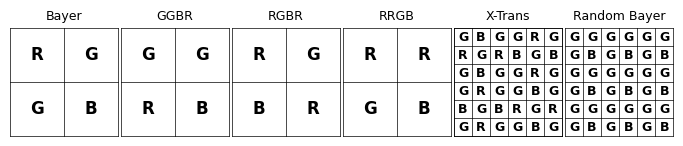

In [11]:
# ── Pixel mask pattern visualization ──────────────────────────────────────────
# Random Bayer: one representative 2×2 block from the chip
rng_vis = np.random.default_rng(0)
mosaic_random_vis = sample_chip_patch(chip_pattern, 2, rng_vis)

def _plot_mosaic_any(ax, mosaic, size=8, fontsize=9):
    """Tile any mosaic unit over a size×size grid (same style as plot_bayer_pattern, light background)."""
    uc_h, uc_w = mosaic.shape
    ax.set_facecolor("white")
    ax.set_xlim(0, size)
    ax.set_ylim(size, 0)
    ax.set_aspect("equal")
    for i in range(size + 1):
        ax.plot([i, i], [0, size], color="black", lw=0.5, clip_on=False)
        ax.plot([0, size], [i, i], color="black", lw=0.5, clip_on=False)
    for row in range(size):
        for col in range(size):
            ax.text(col + 0.5, row + 0.5, mosaic[row % uc_h, col % uc_w],
                    color="black", ha="center", va="center",
                    fontsize=fontsize, fontweight="bold")

_mask_entries = [
    ("Bayer", mosaic_bayer),
    ("GGBR",          mosaic_ggbr),
    ("RGBR",          mosaic_rgbr),
    ("RRGB",          mosaic_rrgb),
    ("X-Trans", mosaic_xtrans),
    ("Random Bayer",  mosaic_random_vis),
]

fig, axs = plt.subplots(1, len(_mask_entries), figsize=(6.69, 1.3), squeeze=True)
fs = plotter.config.font_size

for ax, (name, mosaic) in zip(axs, _mask_entries):
    mosaic = np.array(mosaic)
    if mosaic.shape == (2, 2):
        if name == 'Random Bayer':
            PlottingBase.plot_bayer_pattern(ax, pattern="".join(mosaic.ravel()),
                                        size=6, fontsize=9, dark_background=False)
        else:
            PlottingBase.plot_bayer_pattern(ax, pattern="".join(mosaic.ravel()),
                                        size=2, fontsize=12, dark_background=False)
    else:
        _plot_mosaic_any(ax, mosaic, size=mosaic.shape[0], fontsize=9)
        ax.set_xticklabels('')
        ax.set_yticklabels('')
        ax.set_xticks([])
        ax.set_yticks([])
    ax.set_title(name, fontsize=9)

plt.tight_layout(pad=0.3)
#plt.savefig(os.path.join(save_folder_refactored, "mosaic_patterns_pixel.svg"), dpi=300, format="svg")
plt.show()

/tmp/ipykernel_365146/4161120681.py:80: UserWarning: The figure layout has changed to tight
  fig.tight_layout(pad=0.3)


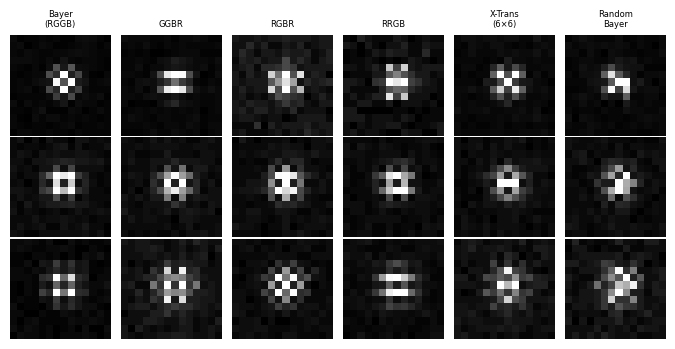

In [12]:
# ── PSF images: 3 dyes × 6 patterns ──────────────────────────────────────────
vis_image_size = 14
vis_pixel_size = 69
vis_NA         = 1.49
vis_background = 4
vis_n_photon   = 4000
vis_dyes       = ["ATTO 488", "ATTO 565", "ATTO 647N"]
vis_filters    = []

# One representative random patch for visualisation
rng_vis = np.random.default_rng(0)
mosaic_random_vis = sample_chip_patch(chip_pattern, vis_image_size, rng_vis)

pattern_mosaics = {
    "Bayer\n(RGGB)":   mosaic_bayer,
    "GGBR":            mosaic_ggbr,
    "RGBR":            mosaic_rgbr,
    "RRGB":            mosaic_rrgb,
    "X-Trans\n(6×6)":  mosaic_xtrans,
    "Random\nBayer":   mosaic_random_vis,
}

R_eff, G_eff, B_eff, wavelength_vis = S_F.getpixelefficiency()
pixel_QYs_vis = np.vstack([B_eff, G_eff, R_eff])

x0_vis = (vis_image_size // 2) * vis_pixel_size
y0_vis = (vis_image_size // 2) * vis_pixel_size

n_patterns = len(pattern_mosaics)
n_dyes_vis = len(vis_dyes)
fig, axs = plt.subplots(
    nrows=n_dyes_vis, ncols=n_patterns,
    figsize=(6.69, 6.69 * n_dyes_vis / n_patterns),
    squeeze=False,
)

fs = plotter.config.font_size

for col, (pname, mosaic) in enumerate(pattern_mosaics.items()):
    masks_vis = M_F.get_masks(size_x=vis_image_size, size_y=vis_image_size, mosaic_unit=mosaic)
    cam_vis = {
        "gain":               np.full((vis_image_size, vis_image_size), np.median(gain)),
        "offset":             np.full((vis_image_size, vis_image_size), np.median(offset)),
        "variance":           np.full((vis_image_size, vis_image_size), np.median(variance)),
        "readnoise":          float(np.median(readnoise)),
        "rqe":                np.full((vis_image_size, vis_image_size), np.median(rqe)),
        "masks":              masks_vis,
        "pixel_QYs":          pixel_QYs_vis,
        "pixel_order":        ["B", "G", "R"],
        "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
    }
    for row, dye in enumerate(vis_dyes):
        ax = axs[row, col]
        aew, dpe = S_F.get_pixel_fractions_dye_and_filters(
            dye, vis_filters, wavelength_vis, pixel_QYs_vis
        )
        n_ph_vis  = {dye: np.full(1, vis_n_photon)}
        x0y0_vis  = {dye: np.zeros([1, 2, 1])}
        x0y0_vis[dye][:, :, :] = np.array([[y0_vis, x0_vis]]).T

        img, _, _ = MSF.gen_camera_image_stack(
            cam_vis, wavelength_vis,
            np.array(aew), np.array(dpe),
            n_ph_vis, x0y0_vis,
            background_photons=vis_background,
            smoothing_function=smoothing_function,
            NA=vis_NA, pixel_size=vis_pixel_size,
            return_normal_image=False,
        )
        plotter.image_plot(
            ax, img, colorbar=False,
            scalebarsize=200, pixelsize=vis_pixel_size, scalebarlabel="200 nm",
            scalebar_color="white", origin="lower",
        )
        if row == 0:
            ax.set_title(pname, fontsize=fs - 1)
        if col == 0:
            ax.set_ylabel(dye, fontsize=fs - 1)

fig.tight_layout(pad=0.3)
#plt.savefig(os.path.join(save_folder_refactored, "psf_images_new_patterns.svg"),
#            dpi=300, format="svg")
plt.show()

In [14]:
# ── Simulation config for new patterns ────────────────────────────────────────
sim_image_size = 14
sim_pixel_size = 69
sim_NA         = 1.49
sim_dyes       = ["ATTO 488", "ATTO 565", "ATTO 647N"]
sim_filters    = []

n_photon_space_new = np.unique(
    np.around(np.logspace(np.log10(500), np.log10(50000), 200) / 5) * 5
)

config_new = SimulationConfig(
    n_bootstrap=100000,
    background_photons=5.0,
    NA=sim_NA,
    pixel_size=sim_pixel_size,
    save_raw_results=True,
    subtractx0y0=False,
    saverawimages=False,
    verbose=False,
    use_stochastic_photons=True,
    n_unit_cells=7,
)

R_sim, G_sim, B_sim, wavelength_sim = S_F.getpixelefficiency()
pixel_QYs_sim = np.vstack([B_sim, G_sim, R_sim])

# Random Bayer: draw ONE per-frame mask stack -- config_new.n_bootstrap
# independent random 14x14 crops from the chip-wide unconstrained pattern above,
# one per bootstrap sample. Drawn once here and reused for every dye's
# test_simulation_method call below (which internally sweeps all photon levels
# for one dye per call), so bootstrap index k always corresponds to the same
# random-arrangement draw across every photon level and every dye in this sweep.
rng_random_bayer = np.random.default_rng(123)
random_bayer_patches = sample_chip_patches_batch(
    chip_pattern, sim_image_size, config_new.n_bootstrap, rng_random_bayer
)
masks_random_bayer = {
    "B": random_bayer_patches == "B",
    "G": random_bayer_patches == "G",
    "R": random_bayer_patches == "R",
}  # each (n_bootstrap, sim_image_size, sim_image_size) bool -- per-frame mask format

# Pattern registry: name → (mosaic_unit, starting_flag). Random_Bayer's "mosaic"
# slot holds one representative patch (frame 0) for ratio-reporting/visualisation
# only -- the sweep loop below uses masks_random_bayer (the full per-frame stack)
# directly for the actual simulation, not this representative patch.
sim_patterns = {
    "Bayer":        (mosaic_bayer,             "bayer_rggb_"),
    "GGBR":         (mosaic_ggbr,              "ggbr_"),
    "RGBR":         (mosaic_rgbr,              "rgbr_"),
    "RRGB":         (mosaic_rrgb,              "rrgb_"),
    "X-Trans":      (mosaic_xtrans,            "xtrans_"),
    "Random_Bayer": (random_bayer_patches[0],  "random_bayer_s42_"),
}

print("Simulation patterns:")
for name, (mo, flag) in sim_patterns.items():
    n = mo.size
    print(f"  {name:16s}  flag={flag!r:25s}  "
          f"R={np.sum(mo=='R')/n:.3f}  G={np.sum(mo=='G')/n:.3f}  "
          f"B={np.sum(mo=='B')/n:.3f}")
print(f"Random_Bayer (full {config_new.n_bootstrap}-frame per-bootstrap stack): "
      f"R={np.mean(masks_random_bayer['R']):.3f}  "
      f"G={np.mean(masks_random_bayer['G']):.3f}  "
      f"B={np.mean(masks_random_bayer['B']):.3f}")
print(f"\nDyes: {sim_dyes}")
print(f"Photon levels: {len(n_photon_space_new)}  "
      f"({n_photon_space_new[0]:.0f}–{n_photon_space_new[-1]:.0f})")
print(f"Save folder: {save_folder_refactored}")

Simulation patterns:
  Bayer             flag='bayer_rggb_'              R=0.250  G=0.500  B=0.250
  GGBR              flag='ggbr_'                    R=0.250  G=0.500  B=0.250
  RGBR              flag='rgbr_'                    R=0.500  G=0.250  B=0.250
  RRGB              flag='rrgb_'                    R=0.500  G=0.250  B=0.250
  X-Trans           flag='xtrans_'                  R=0.222  G=0.556  B=0.222
  Random_Bayer      flag='random_bayer_s42_'        R=0.230  G=0.531  B=0.240
Random_Bayer (full 100000-frame per-bootstrap stack): R=0.250  G=0.500  B=0.250

Dyes: ['ATTO 488', 'ATTO 565', 'ATTO 647N']
Photon levels: 200  (500–50000)
Save folder: /home/jbeckwith/Documents/Chemistry/Lee/Data/Simulation/20260311_ArbitraryPixelPattern/


In [15]:
# ── Run simulations for all new patterns × dyes ───────────────────────────────
import time as _time

n_total_new = len(sim_patterns) * len(sim_dyes)
i_new = 0
t0_new = _time.time()

for pattern_name, (mosaic, flag) in sim_patterns.items():
    if pattern_name == "Random_Bayer":
        # Per-frame masks: (n_bootstrap, H, W) per colour -- a different,
        # independently-sampled random arrangement for every individual
        # bootstrap sample (built above), rather than one fixed mosaic tile.
        masks_sim = masks_random_bayer
    else:
        masks_sim = M_F.get_masks(
            size_x=sim_image_size, size_y=sim_image_size, mosaic_unit=mosaic
        )
    cam_sim = {
        "gain":                np.full((sim_image_size, sim_image_size), np.median(gain)),
        "offset":              np.full((sim_image_size, sim_image_size), np.median(offset)),
        "variance":            np.full((sim_image_size, sim_image_size), np.median(variance)),
        "readnoise":           float(np.median(readnoise)),
        "rqe":                 np.full((sim_image_size, sim_image_size), np.median(rqe)),
        "masks":               masks_sim,
        "pixel_QYs":           pixel_QYs_sim,
        "pixel_order":         ["B", "G", "R"],
        "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
        "mosaic_unit":          mosaic if pattern_name != "Random_Bayer" else None,
    }
    for dye in sim_dyes:
        i_new += 1
        print(f"[{i_new:2d}/{n_total_new}]  {pattern_name:16s}  {dye}", end="  ")
        try:
            MSF.test_simulation_method(
                dye=dye,
                filters=sim_filters,
                wavelength=wavelength_sim,
                camera_parameters=cam_sim,
                save_folder=save_folder_refactored,
                n_photon_space=n_photon_space_new,
                smoothing_function=smoothing_function,
                strategy=FittingStrategy.STANDARD,
                starting_flag=flag,
                config=config_new,
                overwrite=True,
            )
            elapsed = (_time.time() - t0_new) / 60
            rate    = i_new / elapsed if elapsed > 0 else 0
            eta     = (n_total_new - i_new) / rate if rate > 0 else 0
            print(f"done  ({elapsed:.1f} min, ETA {eta:.1f} min)")
        except Exception as e:
            print(f"FAILED: {e}")

print(f"\nAll new-pattern simulations complete in {(_time.time()-t0_new)/60:.1f} min.")

simulation.multicolour — INFO — 
Completed analysis of 200 photon flux values    Total time: 251.355 min
simulation.multicolour — INFO — Simulation completed for strategy standard


done  (251.4 min, ETA 4273.1 min)


simulation.multicolour — INFO — 
Completed analysis of 200 photon flux values    Total time: 257.501 min
simulation.multicolour — INFO — Simulation completed for strategy standard


done  (508.9 min, ETA 4070.9 min)


simulation.multicolour — INFO — 
Completed analysis of 200 photon flux values    Total time: 257.402 min
simulation.multicolour — INFO — Simulation completed for strategy standard


...

done  (5280.6 min, ETA 660.1 min)


simulation.multicolour — INFO — 
Completed analysis of 200 photon flux values    Total time: 477.133 min
simulation.multicolour — INFO — Simulation completed for strategy standard


done  (5757.8 min, ETA 338.7 min)


simulation.multicolour — INFO — 
Completed analysis of 200 photon flux values    Total time: 471.438 min
simulation.multicolour — INFO — Simulation completed for strategy standard


done  (6229.2 min, ETA 0.0 min)

All new-pattern simulations complete in 6229.2 min.


In [16]:
# ── Load results → build New_Patterns_XR ──────────────────────────────────────
# Dims: [pattern, dye, n_photons, metric]  metrics = ["sigma_xy", "sigma_colour"]
_all_files_new = os.listdir(save_folder_refactored)
_params_new    = ["sigma_xy", "sigma_colour"]
_pattern_names = list(sim_patterns.keys())

New_Patterns_XR = xr.DataArray(
    data=np.full(
        [len(_pattern_names), len(sim_dyes), len(n_photon_space_new), len(_params_new)],
        np.nan,
    ),
    coords={
        "pattern":   _pattern_names,
        "dye":       sim_dyes,
        "n_photons": n_photon_space_new,
        "metric":    _params_new,
    },
    dims=["pattern", "dye", "n_photons", "metric"],
)

for i_p, (pattern_name, (mosaic, flag)) in enumerate(sim_patterns.items()):
    pat_image_size = (config_new.n_unit_cells * mosaic.shape[0]
                      if pattern_name != "Random_Bayer" else sim_image_size)
    for i_d, dye in enumerate(sim_dyes):
        dye_str = dye.replace("/", "-")
        dye_files = [
            os.path.join(save_folder_refactored, f)
            for f in _all_files_new
            if f.startswith(flag) and dye_str in f
        ]
        raw_file  = [f for f in dye_files if "rawresults" in f]
        gt_file   = [f for f in dye_files if "groundtruth" in f]
        ip_file   = [f for f in dye_files if "input_parameters" in f]

        if not raw_file or not gt_file or not ip_file:
            print(f"Missing files for {pattern_name} / {dye}")
            continue

        gt    = pd.read_csv(gt_file[0])
        gt_px = np.vstack([gt["x0"].to_numpy() / sim_pixel_size,
                           gt["y0"].to_numpy() / sim_pixel_size]).T

        dye_BGR     = pd.read_csv(ip_file[0]).to_numpy()[0][-3:]
        colour_true = np.expand_dims(dye_BGR / dye_BGR.sum(), 0)

        df_raw = pd.read_hdf(raw_file[0])

        for k, _ in enumerate(n_photon_space_new):
            sub = df_raw[df_raw["photon_level"] == k]
            filt = ~(
                (sub["xc"] < 0) | (sub["yc"] < 0) |
                (sub["s_x"] < 0) | (sub["s_y"] < 0) |
                (sub["xc"] > pat_image_size) | (sub["yc"] > pat_image_size)
            )
            if filt.sum() < 5:
                continue
            ex = sub["xc"].to_numpy()[filt] - gt_px[filt, 0]
            ey = sub["yc"].to_numpy()[filt] - gt_px[filt, 1]
            New_Patterns_XR[i_p, i_d, k, 0] = (
                np.sqrt((np.nanstd(ex)**2 + np.nanstd(ey)**2) / 2) * sim_pixel_size
            )
            colour = np.vstack([
                sub["A_B"].to_numpy()[filt],
                sub["A_G"].to_numpy()[filt],
                sub["A_R"].to_numpy()[filt],
            ]).T
            New_Patterns_XR[i_p, i_d, k, 1] = float(np.nanstd(cdist(colour, colour_true)))

New_Patterns_XR.to_netcdf(
    os.path.join(save_folder_refactored, "New_Patterns_XR.nc")
)
print(f"Saved  shape={New_Patterns_XR.shape}  dims={list(New_Patterns_XR.dims)}")
n_valid = int(np.sum(~np.isnan(New_Patterns_XR.sel(metric="sigma_xy").values)))
print(f"{n_valid} / {New_Patterns_XR.sel(metric='sigma_xy').size} grid cells filled")

Saved  shape=(6, 3, 200, 2)  dims=['pattern', 'dye', 'n_photons', 'metric']
3600 / 3600 grid cells filled


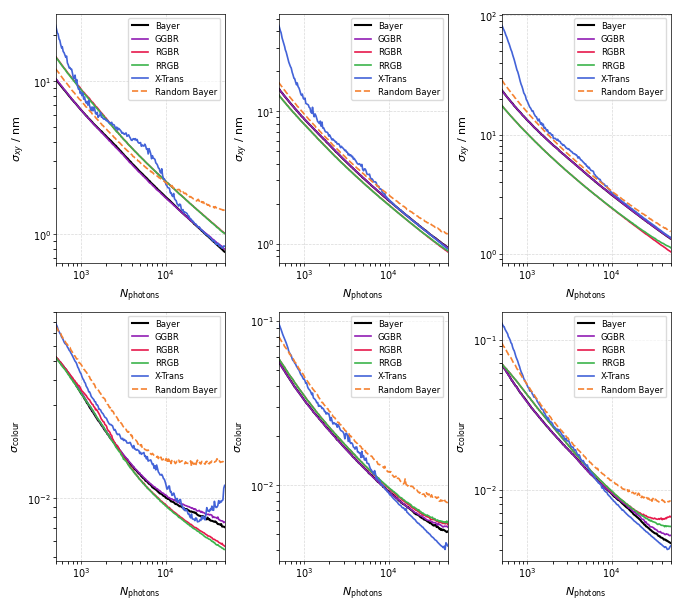

In [18]:
# ── Comparison: σ_xy and σ_colour vs N_photons, all patterns ──────────────────
New_Patterns_XR = xr.load_dataarray(
    os.path.join(save_folder_refactored, "New_Patterns_XR.nc")
)

# Colour / style per pattern — Bayer is the solid black reference line
_pattern_styles = {
    "Bayer":        dict(color="black",    linewidth=1.5, linestyle="-"),
    "GGBR":         dict(color="#911eb4",  linewidth=1.2, linestyle="-"),
    "RGBR":         dict(color="#e6194b",  linewidth=1.2, linestyle="-"),
    "RRGB":         dict(color="#3cb44b",  linewidth=1.2, linestyle="-"),
    "X-Trans":      dict(color="#4363d8",  linewidth=1.2, linestyle="-"),
    "Random_Bayer": dict(color="#f58231",  linewidth=1.2, linestyle="--"),
}

_dyes = ['ATTO 488', 'ATTO 565', 'ATTO 647N']

fig, axs = plotter.two_column_plot(ncols=3, nrows=2, width_ratios=[1,1,1], height_ratios=[1,1])
fs = 8

for ax, metric, ylabel in [
    (axs[0, :], "sigma_xy",     r"$\sigma_{xy}$ / nm"),
    (axs[1, :], "sigma_colour", r"$\sigma_{\rm colour}$"),
]:
    for pattern_name, style in _pattern_styles.items():
            for d_num, dye in enumerate(_dyes):
                y = (New_Patterns_XR.sel(pattern=pattern_name, metric=metric, dye=dye))
                ax[d_num] = plotter.line_plot(ax[d_num], n_photon_space_new, y,
                    label=pattern_name.replace("_", " "), **style)

                ax[d_num].set_xscale("log")
                ax[d_num].set_yscale("log")
                ax[d_num].set_xlabel(r"$N_{\rm photons}$", fontsize=fs)
                ax[d_num].set_ylabel(ylabel, fontsize=fs)
                ax[d_num].set_xlim([n_photon_space_new[0], n_photon_space_new[-1]])
                ax[d_num].tick_params(labelsize=fs-1)
                ax[d_num].legend(loc="best", fontsize=fs - 2, framealpha=0.7)

plt.savefig(
    os.path.join(save_folder_refactored, "new_patterns_precision_comparison.svg"),
    dpi=300, format="svg",
)
plt.show()